In [1]:
from database.db import supabase
import matplotlib.pyplot as plt
import numpy as np
import datetime as dt
from predict import predict_opening_day_by_movie_id_using_knn, ActualPredicted
import time
import seaborn as sns

In [2]:
from database.types import Movie

movies_to_get = 100

movies: list[Movie] = (
    supabase.table("movie")
    .select("id, title")
    .lt("release_date", dt.datetime.now() - dt.timedelta(days=5))
    .gt("budget", 0)
    .order("release_date", desc=True)
    .limit(movies_to_get)
    .execute()
    .data
)

In [3]:
opening_days: list[ActualPredicted] = []
start_time = time.time()
for movie in movies:
    print(f"Predicting opening day for {movie['title']}, {movie['id']}")
    opening_day = predict_opening_day_by_movie_id_using_knn(movie["id"])
    opening_days.append(opening_day)
    print(f"Predicted for {movie['title']}, took {time.time() - start_time:.2f} seconds, {opening_day}")
    start_time = time.time()

Predicting opening day for Snow White, 94399f39-b4c8-43f9-9e41-74f8b98ce2d6
Predicted for Snow White, took 2.65 seconds, {'actual': 16739020, 'predicted': 36281995}
Predicting opening day for The Last Supper, ddd0e8e3-12f2-4b13-ad76-f6ef34518129
Predicted for The Last Supper, took 2.00 seconds, {'actual': 1381229, 'predicted': 736612}
Predicting opening day for The Alto Knights, ec6091bf-9374-4cfc-979e-1c468a1f98fa
Predicted for The Alto Knights, took 1.72 seconds, {'actual': 1205371, 'predicted': 88025}
Predicting opening day for Black Bag, 21b51ade-6e2a-4a25-af75-077e869dd544
Predicted for Black Bag, took 1.98 seconds, {'actual': 3787805, 'predicted': 11789160}
Predicting opening day for Rule Breakers, c01d48d7-387f-47d8-87b4-2d9e530ff120
Predicted for Rule Breakers, took 1.52 seconds, {'actual': 847401, 'predicted': 955678}
Predicting opening day for Mickey 17, 38142eab-6542-460d-9231-d059deee0ba8
Predicted for Mickey 17, took 1.76 seconds, {'actual': 10821735, 'predicted': 8673165}

min_x: 0.001, max_x: 59.976576, min_y: 0.005809, max_y: 54.767322


Text(0.5, 1.0, 'Predicted vs Actual Opening Day')

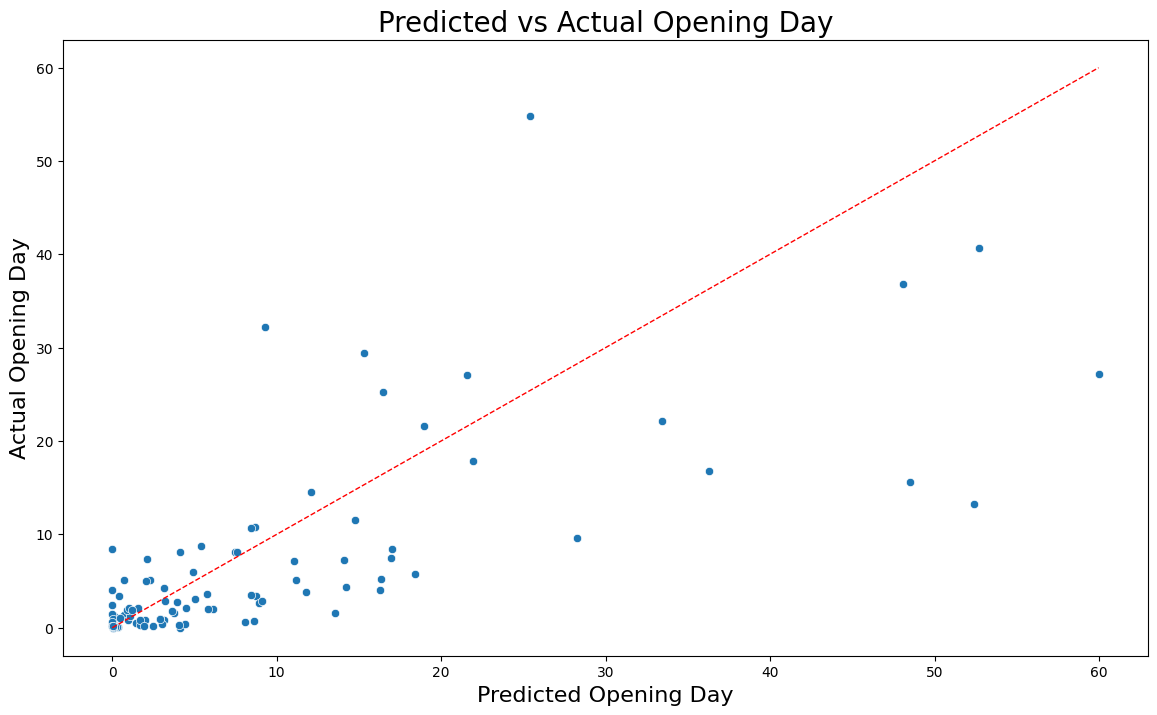

In [7]:
# plot predicted vs actual
xs = [opening_day["predicted"] / 1_000_000 for opening_day in opening_days]
ys = [opening_day["actual"] / 1_000_000 for opening_day in opening_days]

plt.figure(figsize=(14, 8))

sns.scatterplot(
    x=xs,
    y=ys,
)

print(f"min_x: {min(xs)}, max_x: {max(xs)}, min_y: {min(ys)}, max_y: {max(ys)}")

max_x = max(xs)

# add line y=x
plt.plot([0, max_x], [0, max_x], color="red", linestyle="--", linewidth=1)

plt.xlabel("Predicted Opening Day", fontsize=16)
plt.ylabel("Actual Opening Day", fontsize=16)
plt.title("Predicted vs Actual Opening Day", fontsize=20)

In [5]:
# get r2
from sklearn.metrics import r2_score

r2 = r2_score(xs, ys)
print(f"R2: {r2}")

R2: 0.4851433681430235


In [6]:
# now create a model using more traditional techniques instead of the knn
from database.types import OpeningDayDataRPC


opening_day_data: OpeningDayDataRPC = (
    supabase.rpc("opening_day_data")
    .execute()
    .data
)

In [7]:
# convert to a dataframe
import pandas as pd
import datetime as dt

full_opening_day_df = pd.DataFrame(opening_day_data)

# add the log of the youtube_sum_all_views
full_opening_day_df["log_youtube_sum_all_views"] = np.log(
    full_opening_day_df["day_before_youtube_sum_all_views"] + 1
)

# add a column for the day of week for the opening_date
full_opening_day_df["opening_date"] = pd.to_datetime(
    full_opening_day_df["opening_date"]
)
full_opening_day_df["day_of_week"] = full_opening_day_df["opening_date"].dt.dayofweek.astype(str)

# get the training and testing data. Testing is movies in the movies list
opening_day_df = full_opening_day_df[
    ~full_opening_day_df["movie_id"].isin([movie["id"] for movie in movies])
]
# get the movies in the movies list
opening_day_df_test = full_opening_day_df[
    full_opening_day_df["movie_id"].isin([movie["id"] for movie in movies])
]

# then use a robust linear regression model
import statsmodels.api  as sm

formula = "opening_day_revenue ~ 0 + budget + pre_release_cumulative_wikipedia_views : in_franchise + pre_release_cumulative_wikipedia_views : day_before_youtube_sum_all_views"

model = sm.RLM.from_formula(
    formula,
    data=opening_day_df,
).fit()

# run the model on the test data
opening_day_df_test["predicted_opening_day_revenue"] = model.predict(
    opening_day_df_test
)

# get the r2 score
r2 = r2_score(
    opening_day_df_test["opening_day_revenue"],
    opening_day_df_test["predicted_opening_day_revenue"],
)

print(model.summary())

print(f"R2: {r2}")

                     Robust linear Model Regression Results                    
Dep. Variable:     opening_day_revenue   No. Observations:                 2751
Model:                             RLM   Df Residuals:                     2747
Method:                           IRLS   Df Model:                            3
Norm:                           HuberT                                         
Scale Est.:                        mad                                         
Cov Type:                           H1                                         
Date:                 Sat, 29 Mar 2025                                         
Time:                         14:57:03                                         
No. Iterations:                      3                                         
                                                                              coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------

/tmp/ipykernel_38063/2346308184.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  opening_day_df_test["predicted_opening_day_revenue"] = model.predict(


In [8]:
# get the coefficients and save them to a file
coefficients = model.params
print(f"Coefficients: {coefficients}")

Coefficients: budget                                                                     7.190649e-02
pre_release_cumulative_wikipedia_views:in_franchise[False]                 5.205104e-01
pre_release_cumulative_wikipedia_views:in_franchise[True]                  7.749161e+00
pre_release_cumulative_wikipedia_views:day_before_youtube_sum_all_views    4.966822e-08
dtype: float64


Text(0.5, 1.0, 'Predicted vs Actual Opening Day (Robust Linear Regression)')

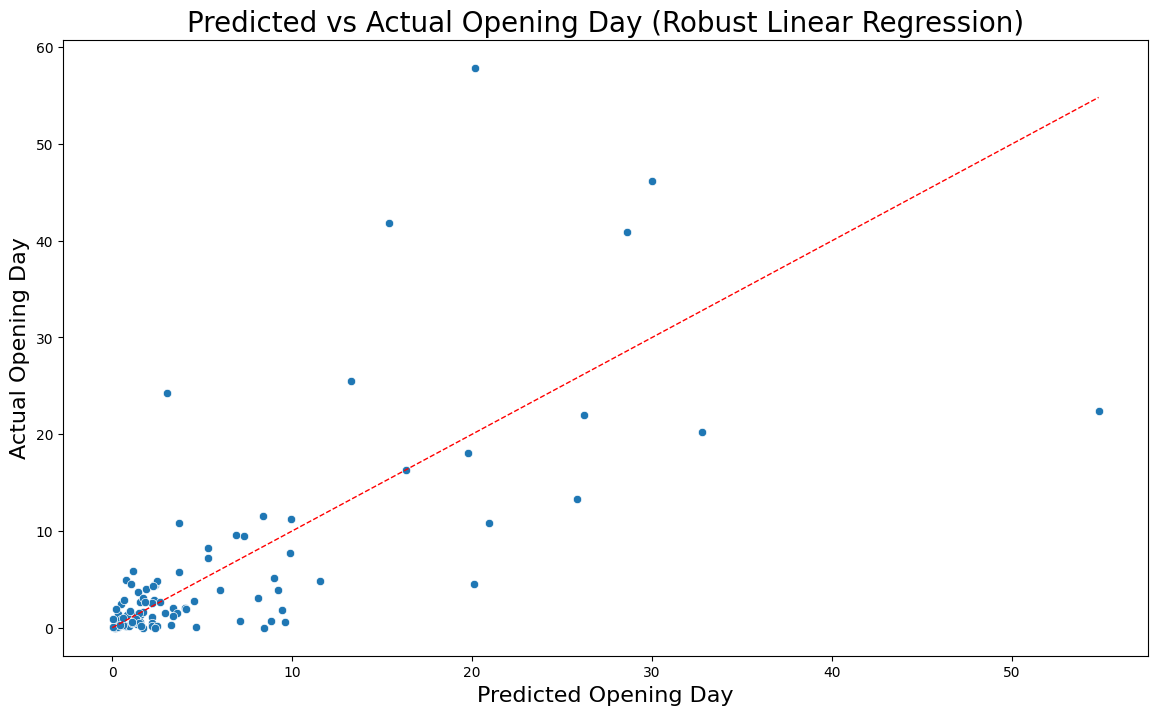

In [9]:
# actual vs predicted
xs = opening_day_df_test["predicted_opening_day_revenue"] / 1_000_000
ys = opening_day_df_test["opening_day_revenue"] / 1_000_000

plt.figure(figsize=(14, 8))
sns.scatterplot(
    x=xs,
    y=ys,
)

max_x = max(xs)

plt.plot([0, max_x], [0, max_x], color="red", linestyle="--", linewidth=1)

# big figsize

plt.xlabel("Predicted Opening Day", fontsize=16)
plt.ylabel("Actual Opening Day", fontsize=16)
plt.title("Predicted vs Actual Opening Day (Robust Linear Regression)", fontsize=20)